In [1]:
import pandas as pd
import numpy as np


In [17]:
import pandas as pd
import numpy as np

# 1. Транзакції (що і коли купили)
orders = pd.DataFrame({
    'order_id': [1, 2, 3, 4, 5, 6, 7, 8],
    'product_id': [10, 11, 10, 12, 11, 10, 13, 12],
    'client_id': [1, 2, 1, 3, 4, 1, 2, 3],
    'qty': [1, 2, 1, np.nan, 1, 2, 1, 5],
    'date': ['2026-03-01', '2026-03-01', '2026-03-02', '2026-03-02', '2026-03-03', '2026-03-04', '2026-03-05', '2026-03-06']
})

# 2. Довідник товарів (категорії та ціни)
products = pd.DataFrame({
    'product_id': [10, 11, 12, 13],
    'p_name': ['iPhone', 'AirPods', 'MacBook', 'iPad'],
    'category': ['Mobile', 'Audio', 'Laptop', 'Tablet'],
    'price': [1000, 200, 2500, 600]
})

# 3. Маркетингові витрати (скільки ми витрачали на рекламу щодня)
marketing = pd.DataFrame({
    'date': ['2026-03-01', '2026-03-02', '2026-03-03', '2026-03-04', '2026-03-05', '2026-03-06'],
    'ad_spend': [100, 150, 80, 200, 50, 120]
})

Твій План Дій (Етап 1: Консолідація)Напиши код, який виконає ці кроки (використовуй все, що ми вчили):

Чистка: Заповни пропуски в qty (кількість) медіаною.

Об'єднання: Склей orders з products (по product_id).

Фінанси: Порахуй колонку revenue ($price \times qty$).

Стиснення: Згрупуй продажі по датах (date), щоб отримати загальну виручку за кожен день.

Фінальний Merge: Склей отриману денну виручку з таблицею marketing по даті.

In [43]:
print(orders.isna().sum())
print(products.isna().sum())
print(marketing.isna().sum())
orders['qty'] = orders['qty'].fillna(np.nanmedian(orders['qty']))
ord_prod = pd.merge(orders, products, on='product_id')
ord_prod['revenue'] = ord_prod['qty'] * ord_prod['price']

grouped = ord_prod.groupby('date')['revenue'].sum().reset_index()
market_ord = pd.merge(grouped, marketing, on='date')

order_id      0
product_id    0
client_id     0
qty           0
date          0
dtype: int64
product_id    0
p_name        0
category      0
price         0
dtype: int64
date        0
ad_spend    0
dtype: int64


In [44]:
market_ord

,date,revenue,ad_spend
0,2026-03-01,1400.0,100
1,2026-03-02,3500.0,150
2,2026-03-03,200.0,80
3,2026-03-04,2000.0,200
4,2026-03-05,600.0,50
5,2026-03-06,12500.0,120


In [45]:
market_ord['profit'] = market_ord['revenue'] - market_ord['ad_spend'] 
market_ord['roi'] = (market_ord['profit']/market_ord['ad_spend'] ) * 100

In [46]:
market_ord

,date,revenue,ad_spend,profit,roi
0,2026-03-01,1400.0,100,1300.0,1300.000000
1,2026-03-02,3500.0,150,3350.0,2233.333333
2,2026-03-03,200.0,80,120.0,150.000000
3,2026-03-04,2000.0,200,1800.0,900.000000
4,2026-03-05,600.0,50,550.0,1100.000000
5,2026-03-06,12500.0,120,12380.0,10316.666667


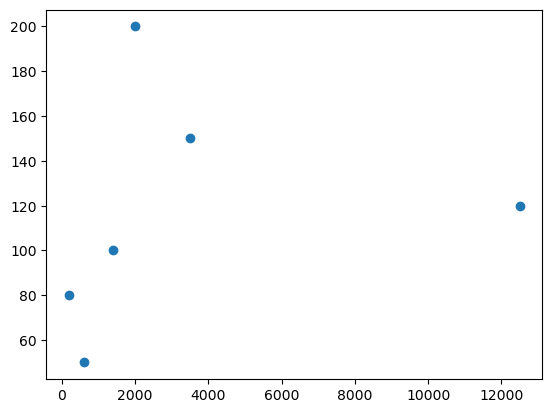

In [47]:
import matplotlib.pyplot as plt


plt.scatter(market_ord['revenue'], market_ord['ad_spend'])

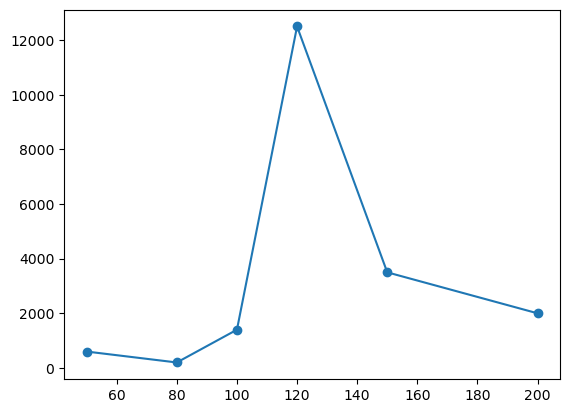

In [48]:
sorted_df = market_ord.sort_values('ad_spend')
plt.plot(sorted_df['ad_spend'], sorted_df['revenue'], marker='o')

In [49]:

group_cat = ord_prod.groupby('category')['revenue'].sum().reset_index()


<BarContainer object of 4 artists>

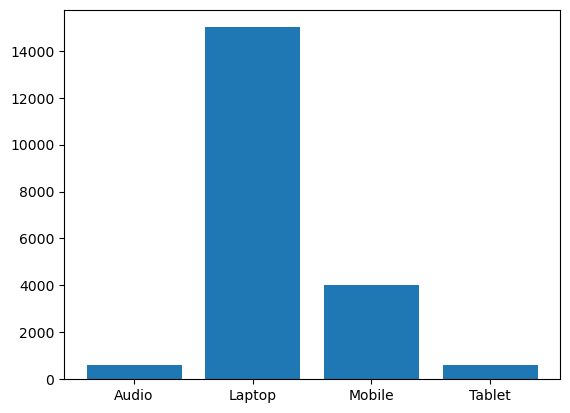

In [50]:
plt.bar(group_cat['category'],group_cat['revenue'])

<BarContainer object of 4 artists>

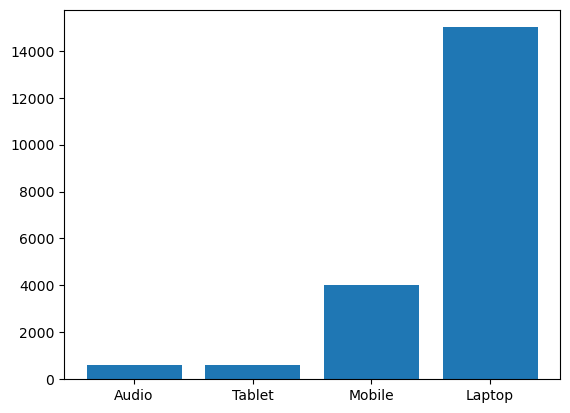

In [51]:
group_cat = group_cat.sort_values('revenue')
plt.bar(group_cat['category'],group_cat['revenue'])

In [52]:
market_ord.head()

,date,revenue,ad_spend,profit,roi
0,2026-03-01,1400.0,100,1300.0,1300.000000
1,2026-03-02,3500.0,150,3350.0,2233.333333
2,2026-03-03,200.0,80,120.0,150.000000
3,2026-03-04,2000.0,200,1800.0,900.000000
4,2026-03-05,600.0,50,550.0,1100.000000


In [53]:
revenue_median = market_ord.loc[market_ord['revenue'] != market_ord['revenue'].max(), 'revenue'].median()
market_ord.loc[market_ord['revenue'] == market_ord['revenue'].max(), 'revenue'] = revenue_median

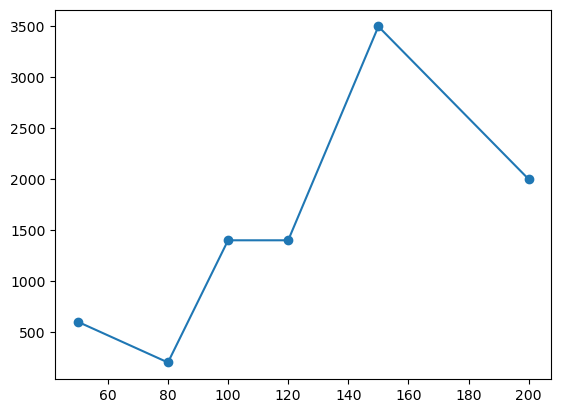

In [54]:
sorted_df = market_ord.sort_values('ad_spend')
plt.plot(sorted_df['ad_spend'], sorted_df['revenue'], marker='o')

In [55]:
market_ord.head()

,date,revenue,ad_spend,profit,roi
0,2026-03-01,1400.0,100,1300.0,1300.000000
1,2026-03-02,3500.0,150,3350.0,2233.333333
2,2026-03-03,200.0,80,120.0,150.000000
3,2026-03-04,2000.0,200,1800.0,900.000000
4,2026-03-05,600.0,50,550.0,1100.000000


In [59]:
market_ord['is_weekend'] = pd.to_datetime(market_ord['date']) 
days = market_ord['is_weekend'].dt.dayofweek

In [60]:
market_ord['is_weekend'] = days.isin([5,6]).astype(int)

In [62]:
market_ord['is_weekend'] 

0    1
1    0
2    0
3    0
4    0
5    0
Name: is_weekend, dtype: int32

In [63]:
from sklearn.linear_model import LinearRegression

In [86]:
x = np.array(market_ord[['ad_spend', 'is_weekend']])
y = np.array(market_ord['revenue'])

model = LinearRegression()
model.fit(x, y)
predictions = model.predict(np.array([[1.5, 0]]))
print(f"Coefficients: {model.coef_}")      # Weights (w1, w2, ...)
print(f"Intercept: {model.intercept_}")
print(f"Прогноз виручки: {predictions[0]:.2f} грн")

Coefficients: [ 15.57971014 171.5942029 ]
Intercept: -329.56521739130426
Прогноз виручки: -306.20 грн
